# YOLOv8 PPE Detection
**Dataset:** Roboflow PPE dataset



## 0. Install dependencies

In [ ]:
!pip install ultralytics roboflow opencv-python matplotlib seaborn PyYAML -q
print('All dependencies installed ✓')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 111.5 MB/s eta 0:00:00
All dependencies installed ✓


## 1. Configure Roboflow credentials



In [ ]:
#  ───────────────────────────────────────────────────────────
RF_API_KEY   = "dvdanOTtjWsYCexlLkNb"
RF_WORKSPACE = "thivyas-workspace"
RF_PROJECT   = "hard-hats-fhbh5-sdrma"
RF_VERSION   = 1
# ─────────────────────────────────────────────────────────────────────────────

assert RF_API_KEY != "YOUR_API_KEY_HERE", "Please set RF_API_KEY above!"
print("Credentials configured ✓")

Credentials configured ✓


## 2. Download dataset from Roboflow

In [ ]:
from roboflow import Roboflow
from pathlib import Path
import yaml

rf      = Roboflow(api_key=RF_API_KEY)
project = rf.workspace(RF_WORKSPACE).project(RF_PROJECT)
dataset = project.version(RF_VERSION).download("yolov8")

DATASET_DIR = dataset.location
YAML_PATH   = f"{DATASET_DIR}/data.yaml"

print(f"Dataset downloaded to : {DATASET_DIR}")
print(f"YAML config           : {YAML_PATH}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Hard-Hats-1 in yolov8:: 100%|██████████| 67059/67059 [00:14<00:00, 4690.99it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset downloaded to : /content/Hard-Hats-1
YAML config           : /content/Hard-Hats-1/data.yaml


## 3. Read class names from the auto-generated YAML

In [ ]:
import yaml

with open(YAML_PATH) as f:
    cfg = yaml.safe_load(f)

CLASS_NAMES = cfg['names']
print(f"Number of classes : {cfg['nc']}")
print(f"Class names       : {CLASS_NAMES}")
print()
print("Full YAML config:")
print(yaml.dump(cfg, default_flow_style=False))

Number of classes : 2
Class names       : ['Hardhat', 'NO-Hardhat']

Full YAML config:
names:
- Hardhat
- NO-Hardhat
nc: 2
roboflow:
  license: CC BY 4.0
  project: hard-hats-fhbh5-sdrma
  url: https://universe.roboflow.com/thivyas-workspace/hard-hats-fhbh5-sdrma/dataset/1
  version: 1
  workspace: thivyas-workspace
test: ../test/images
train: ../train/images
val: ../valid/images



## 4. Inspect dataset structure

In [ ]:
dataset_path = Path(DATASET_DIR)

print(f"{'Split':<10} {'Images':>8} {'Labels':>8}")
print('-' * 30)
for split in ['train', 'valid', 'test']:
    img_dir = dataset_path / split / 'images'
    lbl_dir = dataset_path / split / 'labels'
    imgs   = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png')) if img_dir.exists() else []
    labels = list(lbl_dir.glob('*.txt')) if lbl_dir.exists() else []
    print(f"{split:<10} {len(imgs):>8} {len(labels):>8}")

Split        Images   Labels
------------------------------
train         27564    27564
valid          3962     3962
test           2001     2001


## 5. Exploratory Data Analysis

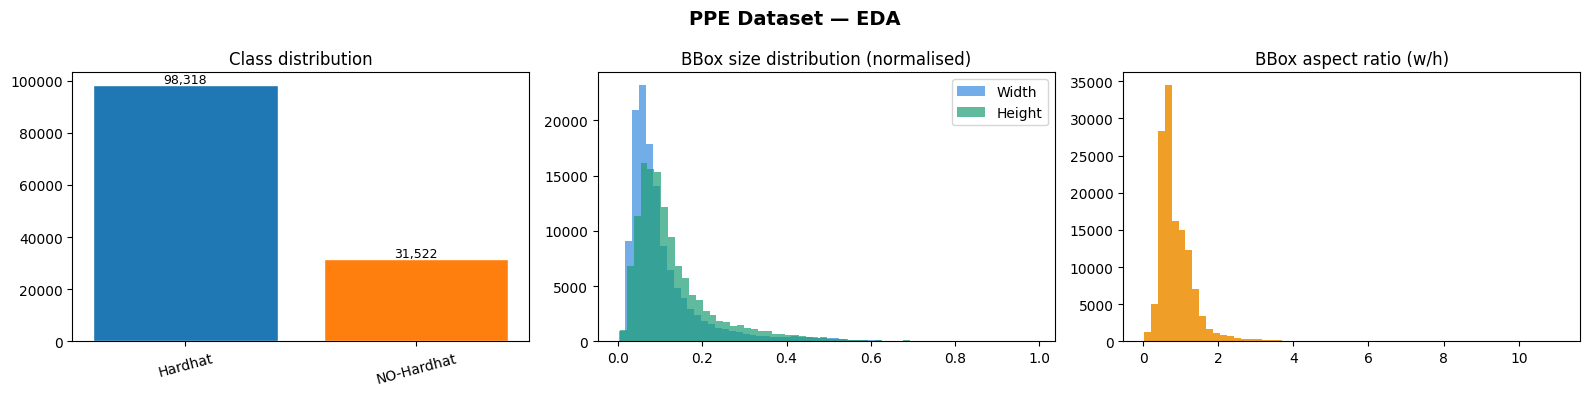

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class_counts = {n: 0 for n in CLASS_NAMES}
widths, heights, aspects = [], [], []

for split in ['train', 'valid', 'test']:
    lbl_dir = dataset_path / split / 'labels'
    if not lbl_dir.exists():
        continue
    for lf in lbl_dir.glob('*.txt'):
        for line in open(lf):
            p = line.strip().split()
            if len(p) < 5:
                continue
            cls, w, h = int(p[0]), float(p[3]), float(p[4])
            if cls < len(CLASS_NAMES):
                class_counts[CLASS_NAMES[cls]] += 1
            widths.append(w)
            heights.append(h)
            aspects.append(w / h if h > 0 else 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('PPE Dataset — EDA', fontsize=14, fontweight='bold')

colors = plt.cm.tab10.colors
axes[0].bar(class_counts.keys(), class_counts.values(),
            color=colors[:len(CLASS_NAMES)], edgecolor='white')
axes[0].set_title('Class distribution')
axes[0].tick_params(axis='x', rotation=15)
for i, (k, v) in enumerate(class_counts.items()):
    axes[0].text(i, v + max(class_counts.values()) * 0.01,
                 f'{v:,}', ha='center', fontsize=9)

axes[1].hist(widths,  bins=60, alpha=0.7, label='Width',  color='#378ADD')
axes[1].hist(heights, bins=60, alpha=0.7, label='Height', color='#1D9E75')
axes[1].set_title('BBox size distribution (normalised)')
axes[1].legend()

axes[2].hist(aspects, bins=60, color='#EF9F27')
axes[2].set_title('BBox aspect ratio (w/h)')

plt.tight_layout()
plt.show()

## 6. Train YOLOv8



In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8m.pt')

results = model.train(
    data          = YAML_PATH,
    epochs        = 100,
    imgsz         = 640,
    batch         = 16,
    lr0           = 0.01,
    lrf           = 0.01,
    warmup_epochs = 3,
    patience      = 20,          # early stopping
    device        = '0',
    project       = 'runs/ppe',
    name          = 'train',
    augment       = True,
    mosaic        = 1.0,
    mixup         = 0.1,
    copy_paste    = 0.1,
    plots         = True,
)

BEST_WEIGHTS = 'runs/ppe/train/weights/best.pt'
print(f'Training complete. Best weights → {BEST_WEIGHTS}')

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 80GB HBM3, 81079MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Hard-Hats-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -r /content/runs/detect/runs/ppe/train /content/drive/MyDrive/ppe_results

## 7. Validate on test split

In [ ]:
BEST_WEIGHTS = '/content/runs/detect/runs/ppe/train/weights/best.pt'
model   = YOLO(BEST_WEIGHTS)
metrics = model.val(data=YAML_PATH, split='test', plots=True)

print(f'mAP@0.50      : {metrics.box.map50:.4f}')
print(f'mAP@0.50:0.95 : {metrics.box.map:.4f}')
print(f'Precision     : {metrics.box.mp:.4f}')
print(f'Recall        : {metrics.box.mr:.4f}')
print()
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name}: AP50 = {metrics.box.ap50[i]:.4f}')

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 80GB HBM3, 81079MiB)
Model summary (fused): 93 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1604.5±645.4 MB/s, size: 67.6 KB)
val: Scanning /content/Hard-Hats-1/test/labels... 2001 images, 27 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2001/2001 2.5Kit/s 0.8s
val: New cache created: /content/Hard-Hats-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 126/126 16.7it/s 7.5s
                   all       2001       5518      0.929       0.94      0.951      0.653
               Hardhat       1626       4480      0.933      0.946      0.961      0.601
            NO-Hardhat        413       1038      0.925      0.934      0.942      0.705
Speed: 0.4ms preprocess, 1.4ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val
mAP@0.50      : 0.9513

## 8. Visualise predictions

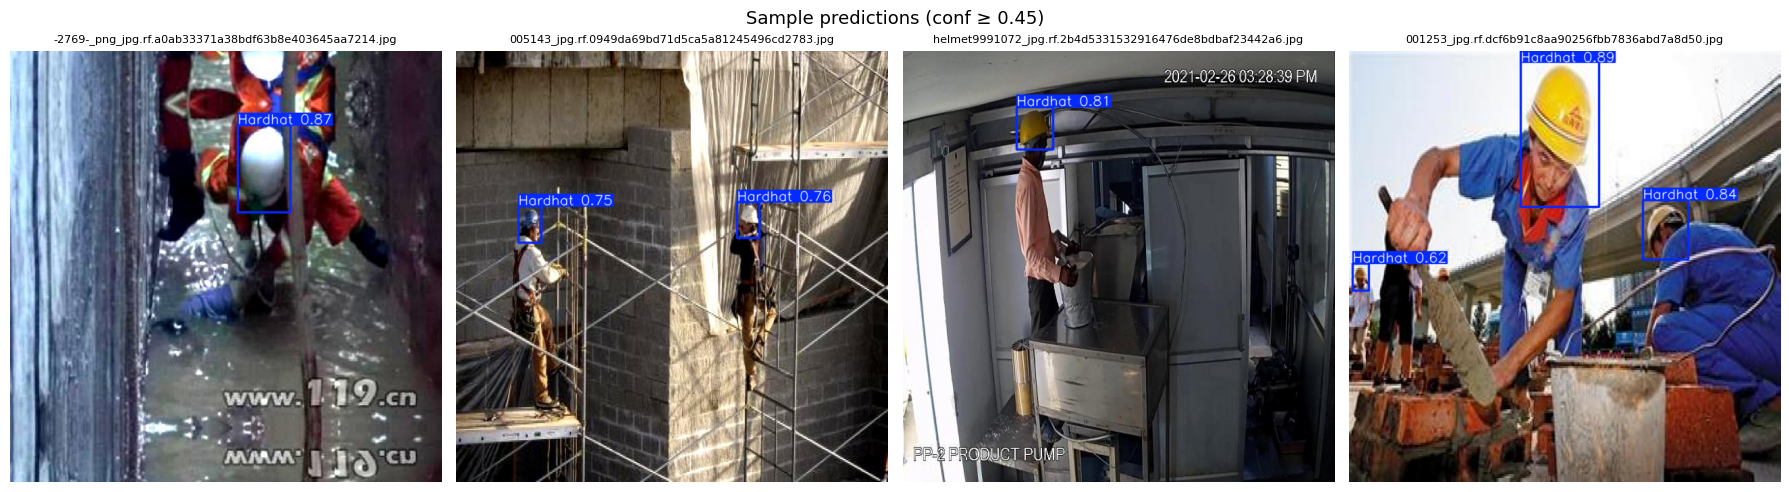

In [ ]:
import cv2, glob, random
import matplotlib.pyplot as plt

# collect test images (jpg + png)
test_images = (glob.glob(f'{DATASET_DIR}/test/images/*.jpg') +
               glob.glob(f'{DATASET_DIR}/test/images/*.png'))

if not test_images:
    # fallback: use valid split
    test_images = (glob.glob(f'{DATASET_DIR}/valid/images/*.jpg') +
                   glob.glob(f'{DATASET_DIR}/valid/images/*.png'))

sample = random.sample(test_images, min(4, len(test_images)))

model = YOLO(BEST_WEIGHTS)
fig, axes = plt.subplots(1, len(sample), figsize=(18, 5))
if len(sample) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample):
    res = model.predict(img_path, conf=0.45, verbose=False)
    annotated = res[0].plot()          # BGR numpy array
    ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    ax.axis('off')
    ax.set_title(Path(img_path).name, fontsize=8)

plt.suptitle('Sample predictions (conf ≥ 0.45)', fontsize=13)
plt.tight_layout()
plt.show()

## 9. PPE Compliance checker

In [ ]:
from pathlib import Path


HELMET_CLASSES = [c for c in CLASS_NAMES if 'helmet' in c.lower() or 'hardhat' in c.lower() or 'hard-hat' in c.lower()]

print(f'Helmet classes : {HELMET_CLASSES}')


def check_compliance(image_path, model, conf=0.45):
    results = model.predict(image_path, conf=conf, verbose=False)
    counts  = {n: 0 for n in CLASS_NAMES}
    for r in results:
        for box in r.boxes:
            counts[CLASS_NAMES[int(box.cls[0])]] += 1

    has_helmet = any(counts[c] > 0 for c in HELMET_CLASSES)
    has_jacket = any(counts[c] > 0 for c in JACKET_CLASSES)

    if has_helmet and has_jacket:
        status = '✅ COMPLIANT — full PPE detected'
    elif not has_helmet and not has_jacket:
        status = '🚨 NO PPE — helmet and jacket missing'
    elif has_helmet:
        status = '⚠️  PARTIAL — reflective jacket missing'
    else:
        status = '⚠️  PARTIAL — safety helmet missing'

    return {'counts': counts, 'status': status,
            'alert': not (has_helmet and has_jacket)}

# Test on a random image
img    = random.choice(test_images)
report = check_compliance(img, model)
print(f'Image  : {Path(img).name}')
print(f'Counts : {report["counts"]}')
print(f'Status : {report["status"]}')

Helmet classes : ['Hardhat', 'NO-Hardhat']
Jacket classes : []
Image  : -2110-_png_jpg.rf.28a0f17e7e39efbef02300ebd056a896.jpg
Counts : {'Hardhat': 3, 'NO-Hardhat': 0}
Status : ⚠️  PARTIAL — reflective jacket missing


## 10. Export to ONNX (for edge deployment)

In [ ]:
model = YOLO(BEST_WEIGHTS)
export_path = model.export(format='onnx', imgsz=640, simplify=True)
print(f'ONNX model exported → {export_path}')

# Optional: also export to TFLite for microcontrollers / Raspberry Pi
tflite_path = model.export(format='tflite', imgsz=640)
print(f'TFLite model exported → {tflite_path}')

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon Platinum 8481C CPU @ 2.70GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 93 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs

PyTorch: starting from '/content/runs/detect/runs/ppe/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (49.6 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 220ms
Prepared 4 packages in 2.67s
Installed 4 packages in 235ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 3.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21

In [ ]:
import yaml

data = {
    "path": "/content/Hard-Hats-1",
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": ["Hardhat", "NO-Hardhat"]
}

with open("data.yaml", "w") as f:
    yaml.dump(data, f)

In [ ]:
from ultralytics import YOLO


model = YOLO('/content/best.pt')

#  int8 quantization at 640x640
tflite_path = model.export(
    format='tflite',
    imgsz=640,
    int8=True,
    data='/content/Hard-Hats-1/data.yaml',
    fraction=0.1
print(f'Exported to: {tflite_path}')

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 93 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs

PyTorch: starting from '/content/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (49.6 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx>=1.12.0,<2.0.0', 'onnx2tf>=1.26.3,<1.29.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 18 packages in 1.93s
Prepared 9 packages in 1.67s
Installed 9 packages in 335ms
 + ai-edge-litert==2.1.4
 + backports-strenum==1.3.1
 + colorama==0.4.6
 + onnx==1.21.0
 + onnx-graphsurgeon==0.6.1
 + onnx2tf==1.28.8
 + onnxruntime==1.24.4
 + onnxslim==0.1.91
 + sng4onnx==2.0.1

re